### Sales Data Analysis & Power BI Dashboard

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [1]:
import pandas as pd
df=pd.read_csv("C:\\CSV FILES\\Superstore sales dataset.csv")
print(df)


      Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2016-152156   8/11/2016  11/11/2016    Second Class   
1          2  CA-2016-152156   8/11/2016  11/11/2016    Second Class   
2          3  CA-2016-138688   12/6/2016   16/6/2016    Second Class   
3          4  US-2015-108966  11/10/2015  18/10/2015  Standard Class   
4          5  US-2015-108966  11/10/2015  18/10/2015  Standard Class   
...      ...             ...         ...         ...             ...   
9989    9990  CA-2014-110422   21/1/2014   23/1/2014    Second Class   
9990    9991  CA-2017-121258   26/2/2017    3/3/2017  Standard Class   
9991    9992  CA-2017-121258   26/2/2017    3/3/2017  Standard Class   
9992    9993  CA-2017-121258   26/2/2017    3/3/2017  Standard Class   
9993    9994  CA-2017-119914    4/5/2017    9/5/2017    Second Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520       Claire Gute   Consumer  United 

In [2]:
print(df.shape)        
print(df.info())       
print(df.isnull().sum())  

(9994, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 1

In [6]:
# Convert Order Date to datetime (day first format)
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
# Check if any invalid dates
print(df['Order Date'].isnull().sum())
# Remove rows with invalid dates
df.dropna(subset=['Order Date'], inplace=True)
# Remove duplicate rows
df.drop_duplicates(inplace=True)


0


In [7]:
# Extract Year and Month
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.month_name()
print(df[['Order Date', 'Year', 'Month', 'Month_Name']].head())

  Order Date  Year  Month Month_Name
0 2016-11-08  2016     11   November
1 2016-11-08  2016     11   November
2 2016-06-12  2016      6       June
3 2015-10-11  2015     10    October
4 2015-10-11  2015     10    October


In [10]:
total_sales = df['Sales'].sum()  # KPI
print("Total Sales:", total_sales)

Total Sales: 2297200.8603


In [12]:
monthly_sales = (
    df.groupby(['Year', 'Month'])['Sales']
    .sum()
    .reset_index()
    .sort_values(['Year', 'Month'])
)

print(monthly_sales.head())
# monthly growth
monthly_sales['Growth_Percentage'] = monthly_sales['Sales'].pct_change() * 100
print(monthly_sales.head())
# top 10 products
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

   Year  Month      Sales
0  2014      1  14236.895
1  2014      2   4519.892
2  2014      3  55691.009
3  2014      4  28295.345
4  2014      5  23648.287
   Year  Month      Sales  Growth_Percentage
0  2014      1  14236.895                NaN
1  2014      2   4519.892         -68.252263
2  2014      3  55691.009        1132.131409
3  2014      4  28295.345         -49.192257
4  2014      5  23648.287         -16.423401
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 33

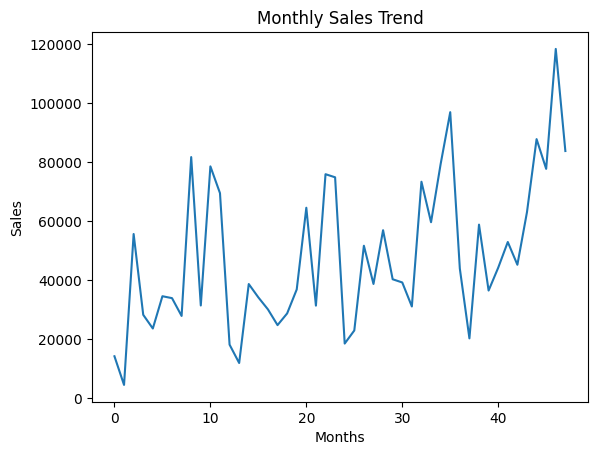

In [13]:
plt.figure()
plt.plot(monthly_sales['Sales'])
plt.title("Monthly Sales Trend")
plt.xlabel("Months")
plt.ylabel("Sales")
plt.show()

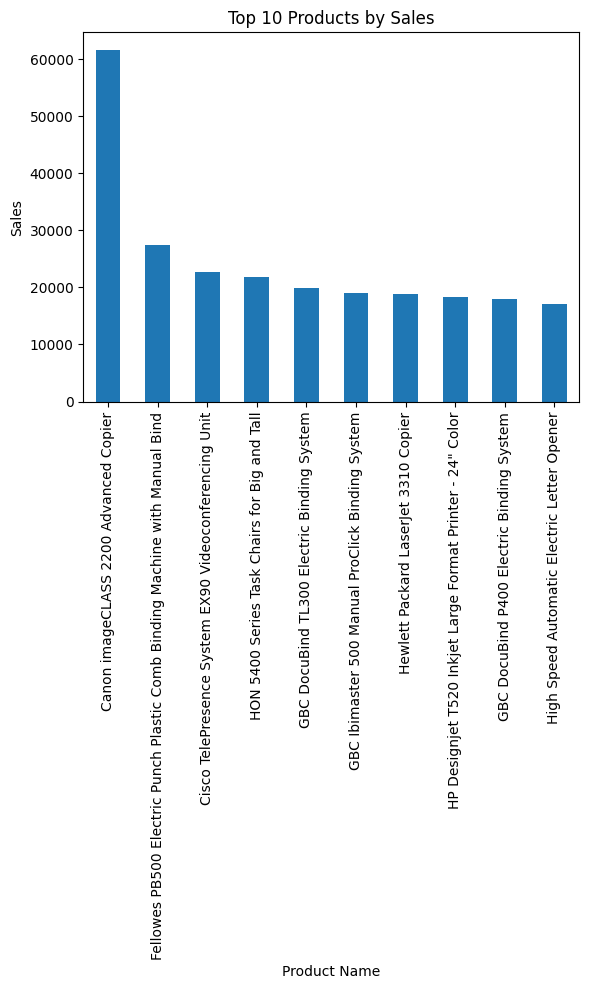

In [16]:
#top 10 products
top_products.plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Sales")
plt.show()

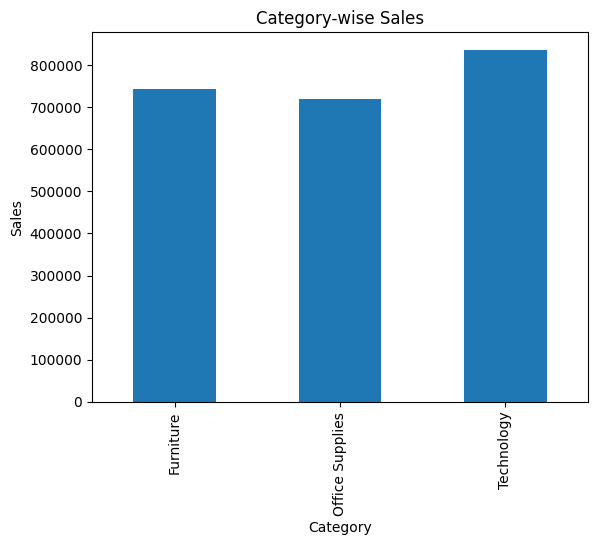

In [17]:
#category wise sales
category_sales = df.groupby('Category')['Sales'].sum()
category_sales.plot(kind='bar')
plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

In [19]:
df.to_csv("cleaned_sales_data.csv", index=False)
print("Cleaned data exported successfully for Power BI")

Cleaned data exported successfully for Power BI


In [1]:
import os
print(os.getcwd())

C:\Users\HP
